# Partitioning Method Comparison

This notebook inspects the metaparameter study results produced by `src/mqt/ionshuttler/multi_shuttler/main2.py`. It normalizes every entry stored in `outputs/simulation_results*.h5` and produces comparison plots between each partitioning strategy across all swept parameters (number of processing zones, ions per zone, grid size, MZ trap size, DAG compilation, and slice-plan enforcement).

Steps covered below:

1. Locate and select the HDF5 run summary you want to analyze.
2. Load it into a tidy pandas DataFrame with normalized partitioning metadata.
3. Use the helper utilities to summarize, visualize, and compare partitioning methods.


## Prerequisites

- Make sure the metaparameter study has been executed so that one or more `simulation_results*.h5` files exist inside `outputs/` (and optionally `outputs/archive/`).
- The notebook relies on `pandas`, `numpy`, `matplotlib`, and `h5py`. If any import fails, install the missing package inside the same environment that launches Jupyter (the project's virtual environment already contains these dependencies).
- Set `RESULTS_FILE` in the next section if you prefer a different results file than the default shown in the table.


In [438]:
from __future__ import annotations

import ast
import json
import os
from datetime import datetime
from pathlib import Path
from typing import Any

import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)
os.environ.setdefault("HDF5_USE_FILE_LOCKING", "FALSE")

plt.style.use("tableau-colorblind10")


In [439]:
def find_project_root(marker: str = "pyproject.toml") -> Path:
    current = Path.cwd()
    for candidate in [current, *current.parents]:
        if (candidate / marker).exists():
            return candidate
    raise FileNotFoundError(f"Could not locate {marker} starting from {current}.")

PROJECT_ROOT = find_project_root()
OUTPUT_DIRS = [PROJECT_ROOT / "outputs/results"]

def list_result_files(pattern: str = "simulation_results*.h5") -> list[Path]:
    files: list[Path] = []
    for directory in OUTPUT_DIRS:
        if directory.exists():
            files.extend(sorted(directory.glob(pattern)))
    files.sort(key=lambda path: path.stat().st_mtime)
    return files

available_result_files = list_result_files()
file_records = []
for path in available_result_files:
    stat = path.stat()
    file_records.append(
        {
            "file": str(path.relative_to(PROJECT_ROOT)),
            "modified": datetime.fromtimestamp(stat.st_mtime).isoformat(timespec="seconds"),
            "size_kb": round(stat.st_size / 1024, 1),
        }
    )

files_df = pd.DataFrame(file_records)
display(files_df if not files_df.empty else "No simulation_results*.h5 files found yet.")

if available_result_files:
    print("Defaulting to the most recently modified file shown above.")
    RESULTS_FILE = available_result_files[-1]
else:
    RESULTS_FILE = PROJECT_ROOT / "outputs" / "simulation_results.h5"

print(f"RESULTS_FILE = {RESULTS_FILE}")
print("Set RESULTS_FILE manually if you prefer a different file.")


,file,modified,size_kb
0,outputs/results/simulation_results.h5,2025-11-10T15:05:40,355.9
1,outputs/results/simulation_results_random_nati...,2025-11-20T16:53:07,2230.0
2,outputs/results/simulation_results_grover-noan...,2025-11-21T12:38:29,93.0
3,outputs/results/simulation_results_random_inde...,2025-11-21T13:02:10,53.9
4,outputs/results/simulation_results_qpeexact_in...,2025-11-21T14:40:05,885.5
5,outputs/results/simulation_results_generated_s...,2025-11-25T10:17:20,343.7
6,outputs/results/simulation_results_generated.h5,2025-11-25T10:22:01,434.4
7,outputs/results/simulation_results_generated_t...,2025-11-25T14:56:12,624.1
8,outputs/results/simulation_results_generated_t...,2025-11-25T15:50:55,189.3
9,outputs/results/simulation_results_generated_t...,2025-11-25T15:52:19,97.3


Defaulting to the most recently modified file shown above.
RESULTS_FILE = /home/linus/code/ionshuttler/outputs/results/simulation_results_generated_global collection.h5
Set RESULTS_FILE manually if you prefer a different file.


## Data loading helpers

The following utilities normalize the HDF5 attributes into plain Python objects, decode the partitioning metadata, and create a tidy DataFrame that includes useful derived columns (such as `total_ions` or a human-readable `grid_label`).


In [440]:
COMPARISON_KEYS = ["grid_size", "mz_trap_size", "num_pzs", "ions_per_pz", "use_dag", "enforce_slice_plan", "algo_sigma", "algo_lookahead_weight_factor", "algo_balance_penalty"]

def normalize_attr(value: Any) -> Any:
    if isinstance(value, bytes):
        return value.decode()
    if isinstance(value, np.generic):
        return value.item()
    return value

def parse_partitioning_attr(raw_value: Any) -> dict[str, Any]:
    normalized = normalize_attr(raw_value)
    if normalized is None:
        return {"method": "none", "label": "none", "params": {}, "raw": normalized}
    if isinstance(normalized, str):
        text = normalized.strip()
        if text.lower() in {"none", "null", ""}:
            return {"method": "none", "label": "none", "params": {}, "raw": normalized}
        try:
            parsed = ast.literal_eval(text)
        except (ValueError, SyntaxError):
            parsed = text
    else:
        parsed = normalized

    if isinstance(parsed, dict):
        method = parsed.get("name") or parsed.get("method") or "custom"
        params = parsed.get("params", {})
    else:
        method = str(parsed)
        params = {}

    label = method
    if params:
        param_str = ", ".join(f"{key}={params[key]}" for key in sorted(params))
        label = f"{method} ({param_str})"

    return {"method": method, "label": label, "params": params, "raw": normalized}

def load_results(file_path: Path) -> tuple[pd.DataFrame, dict[str, Any]]:
    path = Path(file_path).resolve()
    if not path.exists():
        raise FileNotFoundError(f"{path} does not exist.")
    records: list[dict[str, Any]] = []
    with h5py.File(path, "r") as handle:
        if "results" not in handle:
            raise KeyError(f"No 'results' group found in {path}.")
        file_metadata = {key: normalize_attr(value) for key, value in handle.attrs.items()}
        for run_name, run_group in handle["results"].items():
            attrs = {key: normalize_attr(value) for key, value in run_group.attrs.items()}
            entry: dict[str, Any] = {"run_name": run_name, **attrs}
            partition_info = parse_partitioning_attr(entry.pop("partitioning_algorithm", "none"))
            entry["partition_method"] = partition_info["method"]
            entry["partition_variant"] = partition_info["label"]
            entry["partition_params"] = partition_info["params"]
            entry["source_file"] = str(path.relative_to(PROJECT_ROOT))
            entry["total_ions"] = entry["num_pzs"] * entry["ions_per_pz"]
            entry["grid_label"] = f"{entry['grid_size']}x{entry['grid_size']}"
            records.append(entry)

    df = pd.DataFrame(records).sort_values("run_name").reset_index(drop=True)
    bool_columns = ["success", "use_dag", "enforce_slice_plan"]
    for column in bool_columns:
        if column in df.columns:
            df[column] = df[column].astype(bool)
    return df, file_metadata


In [441]:
results_df, file_metadata = load_results(RESULTS_FILE)
print("File metadata:")
print(json.dumps(file_metadata, indent=2))
print(f"Loaded {len(results_df)} runs from {RESULTS_FILE}.")
results_df.head()


File metadata:
{
  "algorithm_name": "generated",
  "base_num_ions": 10,
  "created_at": "2025-12-01T10:07:56.042674",
  "seed": 0
}
Loaded 36 runs from /home/linus/code/ionshuttler/outputs/results/simulation_results_generated_global collection.h5.


,run_name,cpu_time_seconds,enforce_slice_plan,final_timesteps,gate_density,grid_size,ions_per_pz,mz_trap_size,num_ions,num_pzs,plot,save,success,use_dag,partition_method,partition_variant,partition_params,source_file,total_ions,grid_label,algo_balance_penalty,algo_distance_weight_factor,algo_lookahead_weight_factor,algo_max_iterations,algo_sigma,algo_tabu_list_length
0,run_0000,0.145103,False,42,"[0.5, 0.5]",6,3,1,6,4,False,False,True,True,none,none,{},outputs/results/simulation_results_generated_g...,12,6x6,NaN,NaN,NaN,NaN,NaN,NaN
1,run_0001,0.144284,False,36,"[0.5, 0.5]",6,3,1,6,4,False,False,True,True,fgp_tabu,fgp_tabu,{},outputs/results/simulation_results_generated_g...,12,6x6,1.0,1.0,1.0,1000.0,1.0,200.0
2,run_0002,0.132668,False,56,"[0.5, 0.5]",6,3,1,6,4,False,False,True,False,none,none,{},outputs/results/simulation_results_generated_g...,12,6x6,NaN,NaN,NaN,NaN,NaN,NaN
3,run_0003,0.092760,False,43,"[0.5, 0.5]",6,3,1,6,4,False,False,True,False,fgp_tabu,fgp_tabu,{},outputs/results/simulation_results_generated_g...,12,6x6,1.0,1.0,1.0,1000.0,1.0,200.0
4,run_0004,0.331173,False,100,"[0.5, 0.5]",6,3,1,8,4,False,False,True,True,none,none,{},outputs/results/simulation_results_generated_g...,12,6x6,NaN,NaN,NaN,NaN,NaN,NaN


In [442]:
success_df = results_df[results_df["success"]].copy()
print(f"{len(success_df)} successful runs ({len(results_df) - len(success_df)} failures dropped).")
print("Runs per partitioning method:")
display(success_df["partition_method"].value_counts().to_frame(name="count"))
success_df.head()




36 successful runs (0 failures dropped).
Runs per partitioning method:


,count
partition_method,
none,18
fgp_tabu,18


,run_name,cpu_time_seconds,enforce_slice_plan,final_timesteps,gate_density,grid_size,ions_per_pz,mz_trap_size,num_ions,num_pzs,plot,save,success,use_dag,partition_method,partition_variant,partition_params,source_file,total_ions,grid_label,algo_balance_penalty,algo_distance_weight_factor,algo_lookahead_weight_factor,algo_max_iterations,algo_sigma,algo_tabu_list_length
0,run_0000,0.145103,False,42,"[0.5, 0.5]",6,3,1,6,4,False,False,True,True,none,none,{},outputs/results/simulation_results_generated_g...,12,6x6,NaN,NaN,NaN,NaN,NaN,NaN
1,run_0001,0.144284,False,36,"[0.5, 0.5]",6,3,1,6,4,False,False,True,True,fgp_tabu,fgp_tabu,{},outputs/results/simulation_results_generated_g...,12,6x6,1.0,1.0,1.0,1000.0,1.0,200.0
2,run_0002,0.132668,False,56,"[0.5, 0.5]",6,3,1,6,4,False,False,True,False,none,none,{},outputs/results/simulation_results_generated_g...,12,6x6,NaN,NaN,NaN,NaN,NaN,NaN
3,run_0003,0.092760,False,43,"[0.5, 0.5]",6,3,1,6,4,False,False,True,False,fgp_tabu,fgp_tabu,{},outputs/results/simulation_results_generated_g...,12,6x6,1.0,1.0,1.0,1000.0,1.0,200.0
4,run_0004,0.331173,False,100,"[0.5, 0.5]",6,3,1,8,4,False,False,True,True,none,none,{},outputs/results/simulation_results_generated_g...,12,6x6,NaN,NaN,NaN,NaN,NaN,NaN


## Filtering, summaries, and plotting

Use the helpers below to subset the data (`apply_filters`), compute descriptive statistics (`summarize_metric`), and render comparison plots (`plot_metric_by_param`). Provide filters such as `{"use_dag": True, "ions_per_pz": 3}` to focus on a particular slice.


In [443]:

from collections.abc import Mapping

def _normalize_val(v):
    if isinstance(v, np.ndarray):
        v_list = v.tolist()
    elif isinstance(v, list):
        v_list = v
    else:
        return v
    if len(v_list) == 2:
        num, den = v_list
        return float(num)
        return str(float(num))+"/"+str(float(den))
        try:
            den_val = float(den)
            if den_val != 0:
                return float(num) / den_val
        except (TypeError, ValueError):
            pass
    return tuple(v_list)

def _normalize_filters(filt: Mapping[str, Any] | None) -> dict[str, Any]:
    if not filt:
        return {}
    return {k: _normalize_val(v) for k, v in filt.items()}

def _normalize_column(df: pd.DataFrame, column: str) -> pd.DataFrame:
    if column in df.columns:
        df[column] = df[column].map(_normalize_val)
    return df

def apply_filters(df: pd.DataFrame, filters: Mapping[str, Any] | None = None) -> pd.DataFrame:
    filters = _normalize_filters(filters)
    if not filters:
        return df
    filtered = df.copy()
    for key, value in filters.items():
        if key not in filtered.columns:
            continue
        if isinstance(value, (list, tuple, set)):
            mask = filtered[key].isin(value) | filtered[key].isna()
        else:
            mask = (filtered[key] == value) | filtered[key].isna()
        filtered = filtered[mask]
    return filtered

def summarize_metric(
    df: pd.DataFrame,
    metric: str,
    varying_param: str,
    method_col: str = "partition_method",
    agg: str = "median",
    filters: Mapping[str, Any] | None = None,
) -> pd.DataFrame:
    filtered = apply_filters(df, filters)
    if filtered.empty:
        return pd.DataFrame()
    filtered = filtered.copy()
    _normalize_column(filtered, varying_param)
    _normalize_column(filtered, method_col)
    grouped = filtered.groupby([varying_param, method_col])[metric]
    summary = grouped.agg(["count", "mean", "median", "min", "max", "std"]).reset_index()
    if agg not in summary.columns:
        raise ValueError(f"Unsupported aggregation '{agg}'. Available columns: {summary.columns.tolist()}.")
    return summary

def sort_param_values(values: pd.Series) -> list[Any]:
    uniques = pd.unique(values)
    try:
        return sorted(uniques)
    except TypeError:
        return sorted(uniques, key=lambda item: str(item))

def plot_metric_by_param(
    df: pd.DataFrame,
    metric: str,
    varying_param: str,
    method_col: str = "partition_method",
    agg: str = "mean",
    plot_std: bool = True,
    filters: Mapping[str, Any] | None = None,
    param_combinations: Mapping[str, Mapping[str, Any]] | None = None,
) -> tuple[plt.Figure, plt.Axes] | None:
    def summarize_combination(label: str, combo_filters: Mapping[str, Any] | None):
        combined_filters = {**_normalize_filters(filters), **_normalize_filters(combo_filters)}
        filtered_combo = apply_filters(df, combined_filters)
        if filtered_combo.empty:
            return None
        filtered_combo = filtered_combo.copy()
        _normalize_column(filtered_combo, varying_param)
        grouped = filtered_combo.groupby(varying_param)[metric]
        summary = grouped.agg(["count", "mean", "median", "min", "max", "std"]).reset_index()
        if agg not in summary.columns:
            raise ValueError(
                f"Unsupported aggregation '{agg}'. Available columns: {summary.columns.tolist()}."
            )
        summary = summary.rename(columns={agg: metric})
        summary["line_label"] = label
        return summary

    label_context_df = None
    if param_combinations:
        plot_segments: list[pd.DataFrame] = []
        for label, combo_filters in param_combinations.items():
            summary = summarize_combination(label, combo_filters)
            if summary is not None:
                plot_segments.append(summary)
        if not plot_segments:
            return None
        plot_df = pd.concat(plot_segments, ignore_index=True)
    else:
        filtered = apply_filters(df, filters)
        if filtered.empty:
            return None
        filtered = filtered.copy()
        _normalize_column(filtered, varying_param)
        summary = summarize_metric(filtered, metric, varying_param, method_col, agg, filters=None)
        if summary.empty:
            return None
        plot_df = summary[[varying_param, method_col, agg, "std"]].rename(
            columns={agg: metric, method_col: "line_label"}
        )
        label_context_df = filtered

    plot_df = plot_df.copy()
    _normalize_column(plot_df, varying_param)
    is_bool_param = plot_df[varying_param].dtype == bool
    if is_bool_param:
        plot_df[varying_param] = plot_df[varying_param].map({True: "True", False: "False"})
    order = sort_param_values(plot_df[varying_param])
    plot_df[varying_param] = pd.Categorical(plot_df[varying_param], categories=order, ordered=True)
    plot_df["_var_numeric"] = pd.to_numeric(plot_df[varying_param], errors="coerce")
    has_numeric_axis = plot_df["_var_numeric"].notna().all() and not is_bool_param
    plot_df = plot_df.sort_values([varying_param, "line_label"])

    def get_display_name(line_label: str) -> str:
        if param_combinations:
            return line_label
        if str(line_label) != "none":
            return line_label
        use_dag_val = None
        if label_context_df is not None and "use_dag" in label_context_df:
            vals = label_context_df["use_dag"].dropna().unique()
            if len(vals) == 1:
                use_dag_val = bool(vals[0])
        if use_dag_val is True:
            return "vanilla DAG"
        if use_dag_val is False:
            return "vanilla static partition"
        return "vanilla"

    fig, ax = plt.subplots(figsize=(8, 4))
    i = 0
    colors = ["darkviolet", "darkorange", "royalblue", "gold", "forestgreen", "lightgreen", "plum"]
    for label, group_df in plot_df.groupby("line_label"):
        label = str(label)
        group_df = group_df.sort_values(varying_param)
        if has_numeric_axis:
            x_vals = group_df["_var_numeric"]
        else:
            x_vals = group_df[varying_param].astype(str)
        display_label = get_display_name(label)
        line = ax.plot(x_vals, group_df[metric], marker="o", label=display_label, linestyle = "-", color = colors[i])[0]
        if plot_std and "std" in group_df:
            ax.errorbar(
                x_vals,
                group_df[metric],
                yerr=group_df["std"],
                fmt="none",
                capsize=5,
                capthick=1,
                alpha=0.7,
                color=line.get_color(),
            )

        i = i+1

    ax.set_xlabel(varying_param.replace("_", " ").replace("num", "#"))
    ax.set_ylabel(f"{agg} {metric.replace('_', ' ')}")
    title = f"{metric.replace('_', ' ')} vs {varying_param.replace('_', ' ')}"
    if filters:
        filter_desc = ", ".join(f"{key}={value}" for key, value in filters.items())
        title += f" (Filters: {filter_desc})"
    ax.set_title(title)
    ax.legend()
    ax.grid(True, axis="y", linestyle="--", alpha=0.5)
    fig.tight_layout()
    return fig, ax


In [444]:
summarize_metric(success_df, metric="final_timesteps", varying_param="grid_size").head()


,grid_size,partition_method,count,mean,median,min,max,std
0,6,fgp_tabu,18,590.055556,234.0,36,3057,795.945422
1,6,none,18,636.166667,234.5,42,3293,864.879947


plotting with params {'num_pzs': 4, 'ions_per_pz': 3} over num_ions
Base filter matches 36 runs (before specific param filters)
Saved: ../outputs/plots/final_timesteps_by_num_ions_num_pzs_4_ions_per_pz_3.png


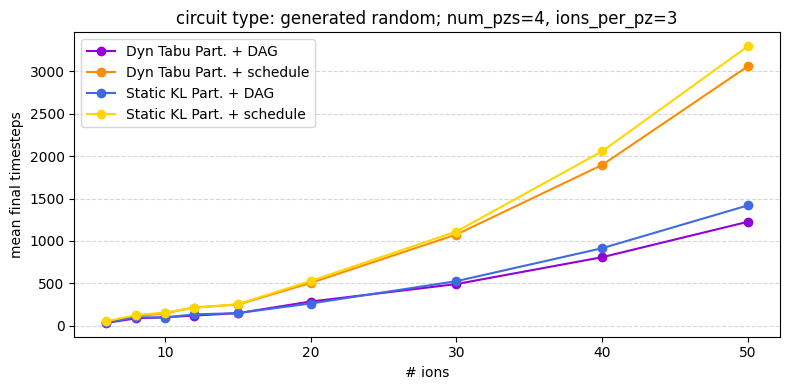

plotting with params {'ions_per_pz': 3} over num_pzs
Base filter matches 36 runs (before specific param filters)
Saved: ../outputs/plots/final_timesteps_by_num_pzs_num_pzs_4_ions_per_pz_3.png


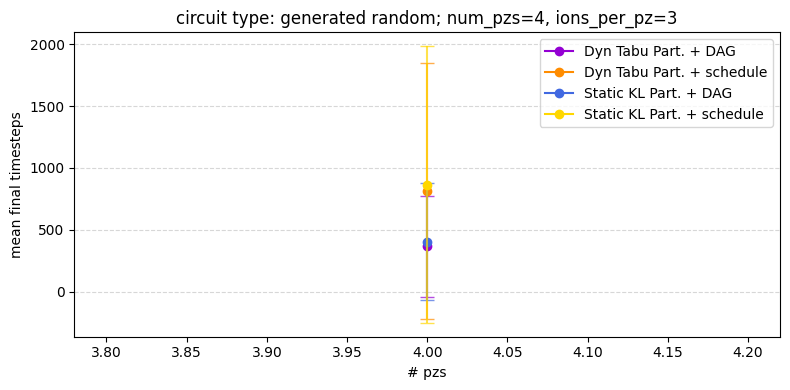

plotting with params {'num_pzs': 4, 'ions_per_pz': 3} over gate_density
Base filter matches 36 runs (before specific param filters)
Saved: ../outputs/plots/final_timesteps_by_gate_density_num_pzs_4_ions_per_pz_3.png


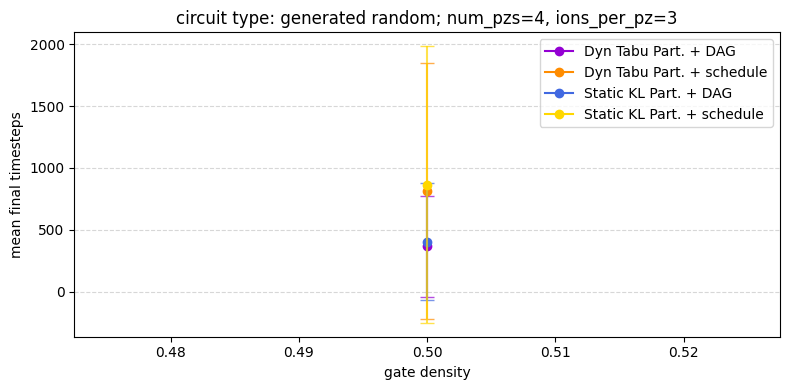

Efficiency Analysis: final_timesteps * cpu_time_seconds
Higher values indicate better efficiency (more timesteps per second of compute)
plotting relative timesteps over num_ions with fixed params: {'num_pzs': 4, 'ions_per_pz': 3}
Filtered to 36 runs (baseline entries=18)
Saved: ../outputs/plots/relative_timesteps_by_num_ions_num_pzs_4_ions_per_pz_3.png


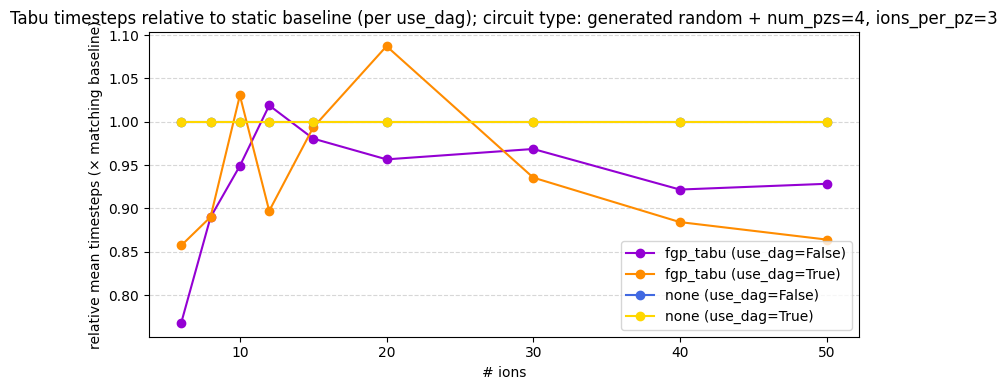

plotting relative timesteps over num_pzs with fixed params: {'ions_per_pz': 3}
Filtered to 36 runs (baseline entries=2)
Saved: ../outputs/plots/relative_timesteps_by_num_pzs_num_pzs_4_ions_per_pz_3.png


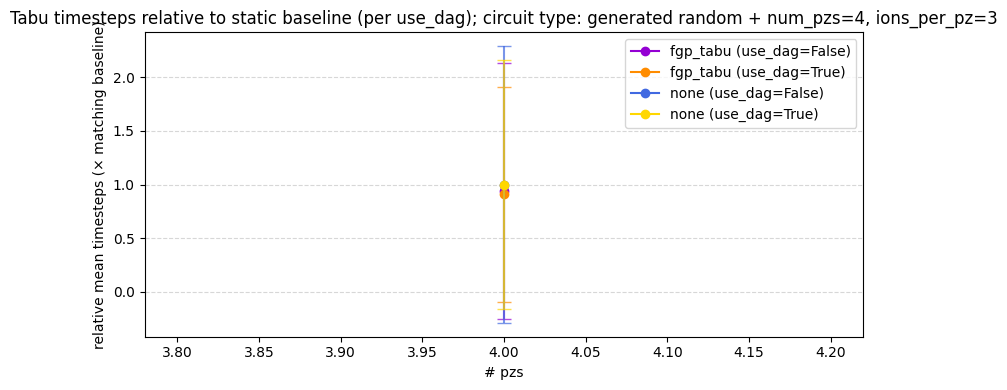

TypeError: unhashable type: 'numpy.ndarray'

In [ ]:

parameters_to_sweep = ["num_ions", "num_pzs", "gate_density"] 
#parameters_to_sweep = ["num_ions", "grid_size", "num_pzs", "algo_sigma"]#, "algo_lookahead_weight_factor", "algo_balance_penalty"]
#parameters_to_sweep = ["num_ions", "grid_size", "num_pzs", "mz_trap_size"]

# Define fixed parameters for filtering
#fixed_params = {"ions_per_pz": 3, "num_pzs": 2, "num_ions": 10}  # Example: fix ions per processing zone to 2
#fixed_params = {"algo_sigma" : 1.88, "algo_balance_penalty": 0.19, "ions_per_pz": 2, "num_pzs": 3, "num_ions": 15}
#fixed_params = {"algo_sigma" : 1.88, "algo_balance_penalty": 0.19, "num_ions": 10, "num_pzs": 2, "ions_per_pz": 2, "grid_size": 3}
#fixed_params = {"use_dag": False}
fixed_params = {"num_pzs": 4, "ions_per_pz": 3}
#fixed_params = {}

specific_param_combinations = {
    "Static KL Part. + schedule" : {"partition_method": "none", "use_dag": False},
    "Static KL Part. + DAG" : {"partition_method": "none", "use_dag": True},
    #"FGP Tabu (enforced)" : {"partition_method": "fgp_tabu", "enforce_slice_plan": True, "use_dag": False},
    "Dyn Tabu Part. + schedule" : {"partition_method": "fgp_tabu", "enforce_slice_plan": False, "use_dag": False},
    "Dyn Tabu Part. + DAG" : {"partition_method": "fgp_tabu", "enforce_slice_plan": False, "use_dag": True},
}


# Create filtered dataset

# Create suffix for filenames and titles
if fixed_params:
    param_suffix = "_".join(f"{key}_{value}" for key, value in fixed_params.items())
    title_suffix = ", ".join(f"{key}={value}" for key, value in fixed_params.items())
else:
    param_suffix = "all"
    title_suffix = "all configurations"

for metric in ["final_timesteps", "cpu_time_seconds"]:
    for param in parameters_to_sweep:
        local_fixed_params = {k: v for k, v in fixed_params.items() if k != param}
        base_filtered = apply_filters(success_df, local_fixed_params)
        print(f"plotting with params {local_fixed_params} over {param}")
        print(f"Base filter matches {len(base_filtered)} runs (before specific param filters)")
        
        result = plot_metric_by_param(
            success_df,
            metric=metric,
            varying_param=param,
            method_col="partition_method",
            filters=local_fixed_params,
            plot_std = True,
            param_combinations=specific_param_combinations,
        )
        if result is None:
            print("No data to plot for this configuration; skipping figure.")
            continue
        fig, ax = result
        # Update title to include fixed parameters
        current_title = ax.get_title()
        circuit_type = file_metadata["algorithm_name"]+str(" random") if "generated" in file_metadata["algorithm_name"] else file_metadata["algorithm_name"]
        fixed_param_string = ", ".join(f"{k}={v}" for k, v in fixed_params.items())
        ax.set_title(f"circuit type: {circuit_type}; {fixed_param_string}")
        # Save with descriptive filename
        filename = f"../outputs/plots/{metric}_by_{param}_{param_suffix}.png"
        plt.savefig(filename)
        print(f"Saved: {filename}")


        plt.show()

    # Compute and plot efficiency metric (final_timesteps / cpu_time_seconds)
    print("Efficiency Analysis: final_timesteps * cpu_time_seconds")
    print("Higher values indicate better efficiency (more timesteps per second of compute)")

    plot_efficiency = False
    if plot_efficiency:
        for param in parameters_to_sweep:
            local_fixed_params = {k: v for k, v in fixed_params.items() if k != param}
            filtered_df = apply_filters(success_df, local_fixed_params)

            if filtered_df.empty:
                print(f"No data for parameter {param} with filters {local_fixed_params}")
                continue

            # Add efficiency metric
            filtered_df = filtered_df.copy()
            filtered_df['efficiency'] = filtered_df['final_timesteps'] * filtered_df['cpu_time_seconds']

            print(f"plotting efficiency over {param} with fixed params: {local_fixed_params}")
            print(f"Filtered to {len(filtered_df)} runs")

            result = plot_metric_by_param(filtered_df, metric="efficiency", varying_param=param, method_col="partition_method")
            if result is None:
                print("No data to plot for this configuration; skipping figure.")
                continue

            fig, ax = result
            current_title = ax.get_title()
            circuit_type = file_metadata["algorithm_name"]+str(" random") if "generated" in file_metadata["algorithm_name"] else file_metadata["algorithm_name"]
            fixed_param_string = ", ".join(f"{k}={v}" for k, v in fixed_params.items())
            ax.set_title(f"circuit type: {circuit_type} + {fixed_param_string}")
            ax.set_ylabel("mean efficiency (timesteps/cpu_second)")

            # Save with descriptive filename
            filename = f"../outputs/plots/efficiency_by_{param}_{param_suffix}.png"
            plt.savefig(filename)
            print(f"Saved: {filename}")
            plt.show()

    plot_relative = True

    if plot_relative:
        for param in parameters_to_sweep:
            local_fixed_params = {k: v for k, v in fixed_params.items() if k != param}
            filtered_df = apply_filters(success_df, local_fixed_params)

            if filtered_df.empty:
                print(f"No data for parameter {param} with filters {local_fixed_params}")
                continue

            # Baselines per (use_dag, param value) for static partition_method="none"
            baseline_mask = filtered_df["partition_method"].eq("none")
            baseline_grouped = filtered_df.loc[baseline_mask].groupby(["use_dag", param])["final_timesteps"].mean()
            if baseline_grouped.empty:
                print(f"No baseline data for parameter {param} with filters {local_fixed_params}; skipping relative plot.")
                continue

            filtered_df_local = filtered_df.copy()
            filtered_df_local["baseline_mean"] = filtered_df_local.apply(
                lambda row: baseline_grouped.get((row["use_dag"], row[param])), axis=1
            )
            filtered_df_local = filtered_df_local.dropna(subset=["baseline_mean"])
            if filtered_df_local.empty:
                print(f"No overlapping baseline data for parameter {param}; skipping relative plot.")
                continue

            # Only compare tabu vs its matching baseline, and keep use_dag separate
            filtered_df_local = filtered_df_local[filtered_df_local["partition_method"].isin(["fgp_tabu", "none"])]
            filtered_df_local['relative_timesteps'] = filtered_df_local['final_timesteps'] / filtered_df_local['baseline_mean']
            filtered_df_local['method_label'] = filtered_df_local.apply(
                lambda row: f"{row['partition_method']} (use_dag={row['use_dag']})", axis=1
            )

            print(f"plotting relative timesteps over {param} with fixed params: {local_fixed_params}")
            print(f"Filtered to {len(filtered_df_local)} runs (baseline entries={len(baseline_grouped)})")

            result = plot_metric_by_param(
                filtered_df_local,
                metric="relative_timesteps",
                varying_param=param,
                method_col="method_label",
                param_combinations=specific_param_combinations,
                filters=local_fixed_params,
            )
            if result is None:
                print("No data to plot for this configuration; skipping figure.")
                continue

            fig, ax = result
            current_title = ax.get_title()
            circuit_type = file_metadata["algorithm_name"]+str(" random") if "generated" in file_metadata["algorithm_name"] else file_metadata["algorithm_name"]
            fixed_param_string = ", ".join(f"{k}={v}" for k, v in fixed_params.items())
            ax.set_title(f"Tabu timesteps relative to static baseline (per use_dag); circuit type: {circuit_type} + {fixed_param_string}")
            ax.set_ylabel("relative mean timesteps")

            # Save with descriptive filename
            filename = f"../outputs/plots/relative_timesteps_by_{param}_{param_suffix}.png"
            plt.savefig(filename)
            print(f"Saved: {filename}")
            plt.show()


### Optional: compare full partition variants

Use the `partition_variant` column when you want to distinguish between different parameterizations of the same algorithm (for example different `num_clusters` values of `fgp_roee`).


In [ ]:
for metric in []:#("final_timesteps", "cpu_time_seconds"):
    print(f"### {metric} (partition variants)")
    for param in parameters_to_sweep:
        fig, _ = plot_metric_by_param(success_df, metric=metric, varying_param=param)
        plt.show()
